<a href="https://colab.research.google.com/github/NahomKidane/ai301-labs/blob/main/m05-clustering-and-topic-modeling/guided-labs/AI301_Guided_Lab_Part1_Library_Clustering_Documents_TYPEALONG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI 301 Guided Lab: Clustering and Topic Modeling, Part 1 · Clustering Documents (type along)

**Module 5 · Clustering and Topic Modeling**

> **File > Save a copy in Drive** before you start. Switch the runtime on: **Runtime > Change
> runtime type > T4 GPU**. This notebook embeds 5,000 abstracts, which is slow on a CPU. It
> downloads one dataset of about 53 MB and one embedding model of about 67 MB.

This notebook groups 5,000 research abstracts by topic without any labels. The pipeline has three
steps, each in its own part:

1. **Embeddings**: turn each abstract into a vector of 384 numbers, Part 2.
2. **Dimensionality Reduction**: we will use UMAP to reduce each vector to 5 numbers, Part 3.
3. **Clustering**: we will use HDBSCAN to group the reduced vectors into clusters, Part 4.

Parts 5 and 6 read and plot the clusters, and Part 7 changes the one setting HDBSCAN needs. The
appendix runs k-means on the same vectors and compares the two clusterings.

You type the code in this copy. Where a block is marked **Type this yourself**, type it into the empty cell underneath and run it. Setup, data loading, the plots and the helpers are already filled in, because they are not what this lab is about.

In [ ]:
%pip install -q umap-learn hdbscan sentence-transformers plotly

---

## Part 0 · Setup

In [ ]:
# UMAP and scikit-learn print warnings about parallelism and renamed arguments, neither is an error
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

## Part 1 · The dataset

The dataset holds **44,949 abstracts** from the arXiv category Computation and Language (cs.CL), the
arXiv section for NLP research.

Every row has four fields: `Titles`, `Abstracts`, `Years`, and `Categories`. `Categories` holds the
same value, Computation and Language, on every row. There is no topic label.

Embedding all **44,949 abstracts** is slow in a class session, so we take a random sample of 5,000.

- **Python note:** `shuffle(seed=42)` puts the rows in a random order that is the same on every run,
  and `select(range(5000))` keeps the first 5,000 rows of that order. `list(...)` turns a column into
  a plain Python list, which is what the embedding model expects.

> **Predict before running.**
>
> These abstracts cover about thirty years of NLP research. Name three research areas you expect
> to come out as separate groups.

**Your prediction:**

_Type here._

> Dataset card: [maartengr/arxiv_nlp](https://huggingface.co/datasets/maartengr/arxiv_nlp). Read
> it to see where the abstracts came from and which years they cover, since both affect what topics
> can appear in the clusters.

In [ ]:
from datasets import load_dataset

# the dataset has a single split, train
dataset = load_dataset("maartengr/arxiv_nlp", split="train")
print("full dataset:", len(dataset), "abstracts")

# random order, fixed by the seed, then keep the first 5,000
# You can test on the full 40k+ dataset
dataset = dataset.shuffle(seed=42).select(range(5000))

abstracts = list(dataset["Abstracts"])
titles = list(dataset["Titles"])
years = list(dataset["Years"])

print("sample:", len(abstracts), "abstracts")
print("years:", min(years), "to", max(years))
print()

# the title, year and first 300 characters of three abstracts
for i in range(3):
    print(titles[i], "(" + str(years[i]) + ")")
    print(abstracts[i][:300])
    print()

**Interpret the output.**

1. There is no topic label to check the clusters against. Say how you will decide whether a cluster
   is good, and what that method costs you when there are dozens of clusters.
2. The sample is random. Name one kind of topic that is more likely to be lost in a 5,000 sample
   than in the full 44,949.

**Your answer:**

_Type here._

---

## Part 2 · Embeddings

This is the same step as Part 2 of the Module 4 guided lab: a frozen sentence embedding model turns
each abstract into one vector. The model here is `gte-small`, which returns 384 numbers per text.

> **Predict before running.**
>
> 1. What shape will `embeddings` have?
> 2. Two abstracts on the same problem use different vocabulary; one says "machine translation" and
>    the other "MT". Will their vectors be close?

**Your prediction:**

_Type here._

> Model card: [thenlper/gte-small](https://huggingface.co/thenlper/gte-small). Read it for the
> maximum input length and what the model was trained on, since an abstract longer than the limit
> is cut off before it is embedded.

> **Type this yourself.**
>
> ```python
> from sentence_transformers import SentenceTransformer
> 
> embedding_model = SentenceTransformer("thenlper/gte-small")
> 
> # one vector per abstract
> embeddings = embedding_model.encode(abstracts, show_progress_bar=True)
> 
> print("shape:", embeddings.shape)
> ```

In [ ]:
# Type the embedding cell above here, then run it.


**Interpret the output.**

1. Say what each row of `embeddings` stands for, and which of the two numbers in the shape would
   change if you swapped in the Module 4 model.
2. Nothing in this cell mentions topics. Say where the topic information that the clusters will
   use actually comes from.

**Your answer:**

_Type here._

---

## Part 3 · UMAP

HDBSCAN, the next step, finds clusters by looking for regions where points sit close together. That
needs distances that mean something, and in 384 dimensions they stop meaning much: as the number of
dimensions grows, the nearest pair of points and the farthest pair end up at similar distances.

The first figure, from ITS 201, shows the same twenty points in one, two and three attributes:
each added attribute multiplies the space the points have to fill, so most of it ends up empty.

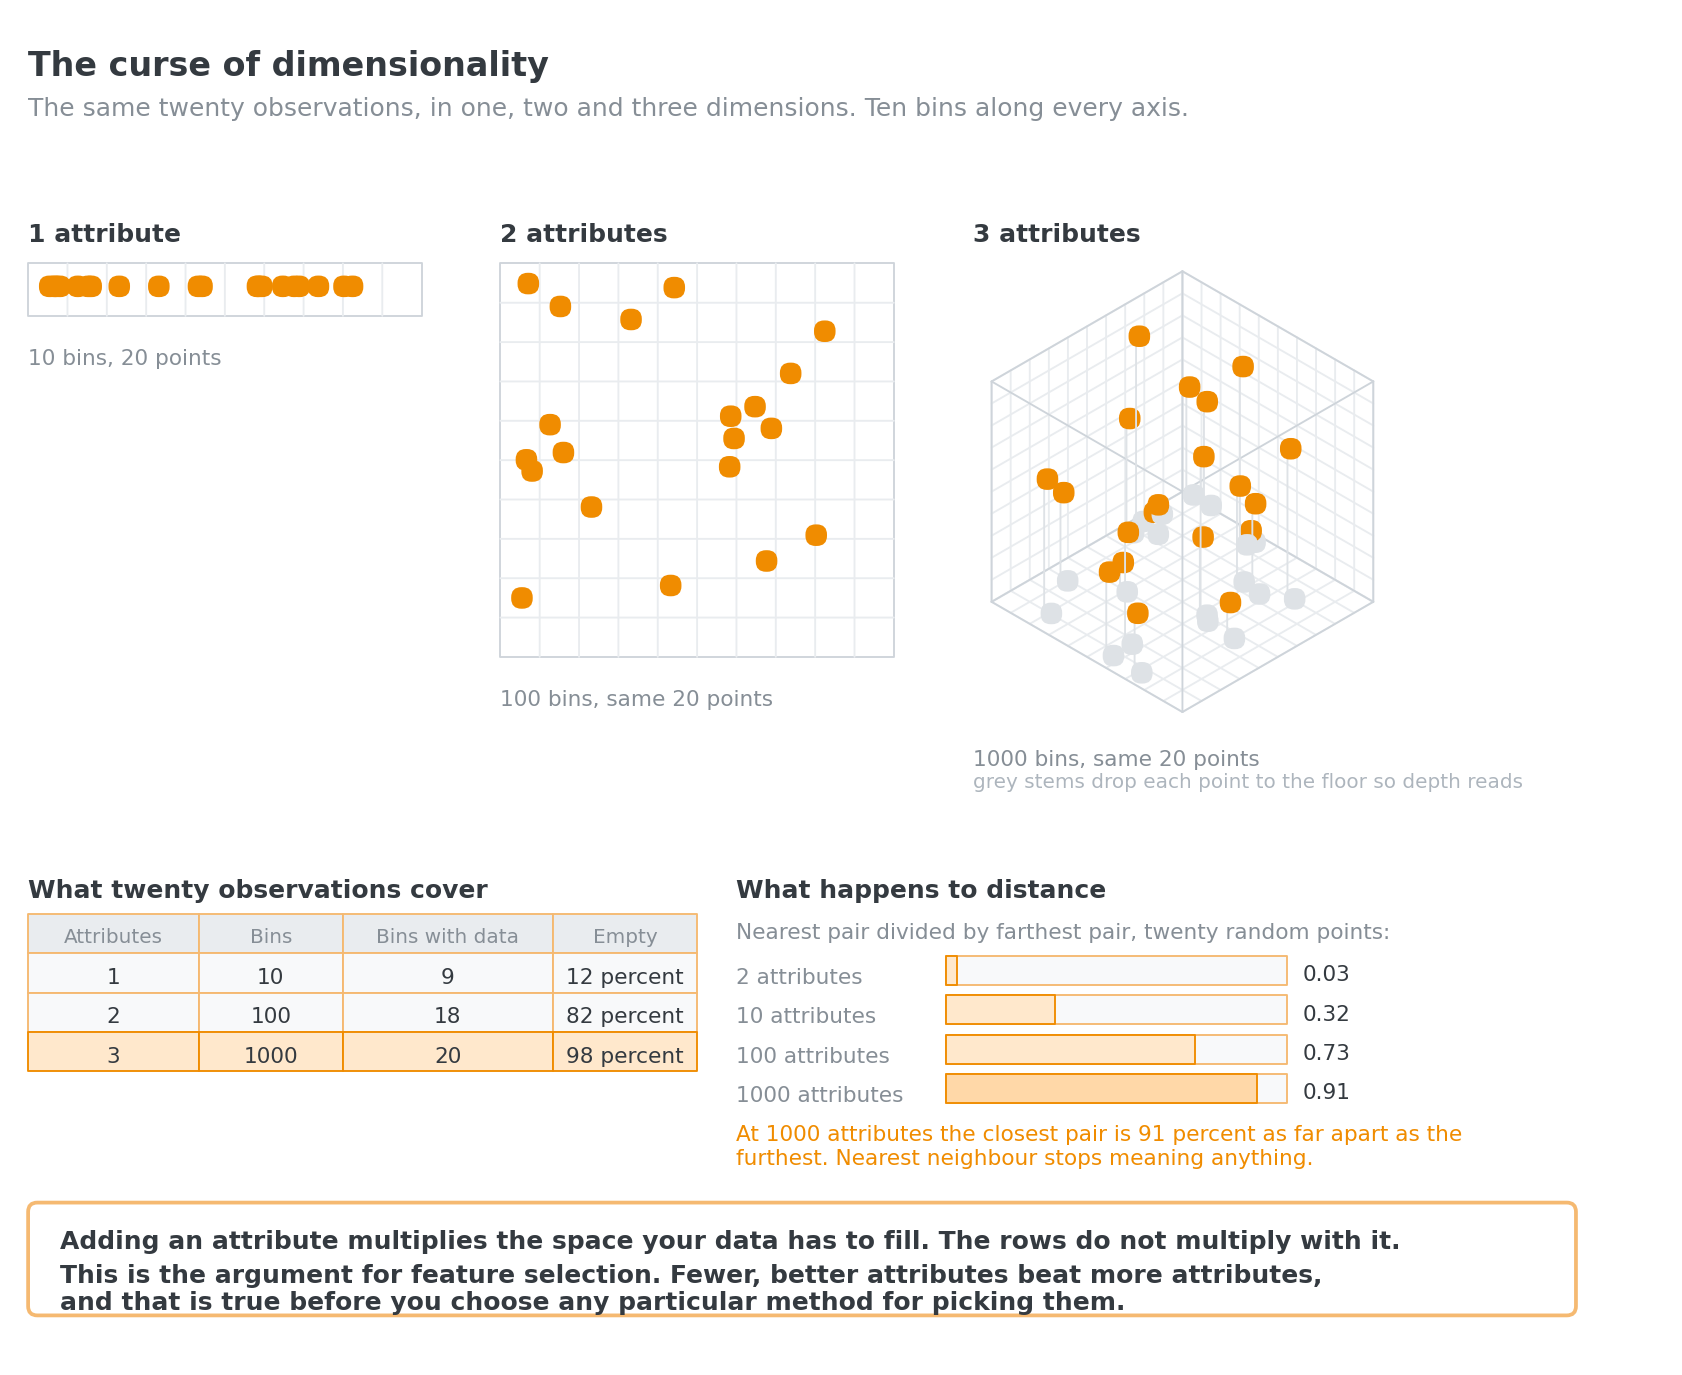

The second figure applies the same idea to the sizes this lab uses, on 1,000 random points. With 2
attributes, the nearest pair is almost no distance apart compared with the farthest pair. With 384
attributes, the size of a gte-small vector, it is 76 percent, and the right panel shows why: almost
every pair of points sits at about the same distance. The points are random, not text embeddings;
real embeddings have structure, which UMAP preserves.

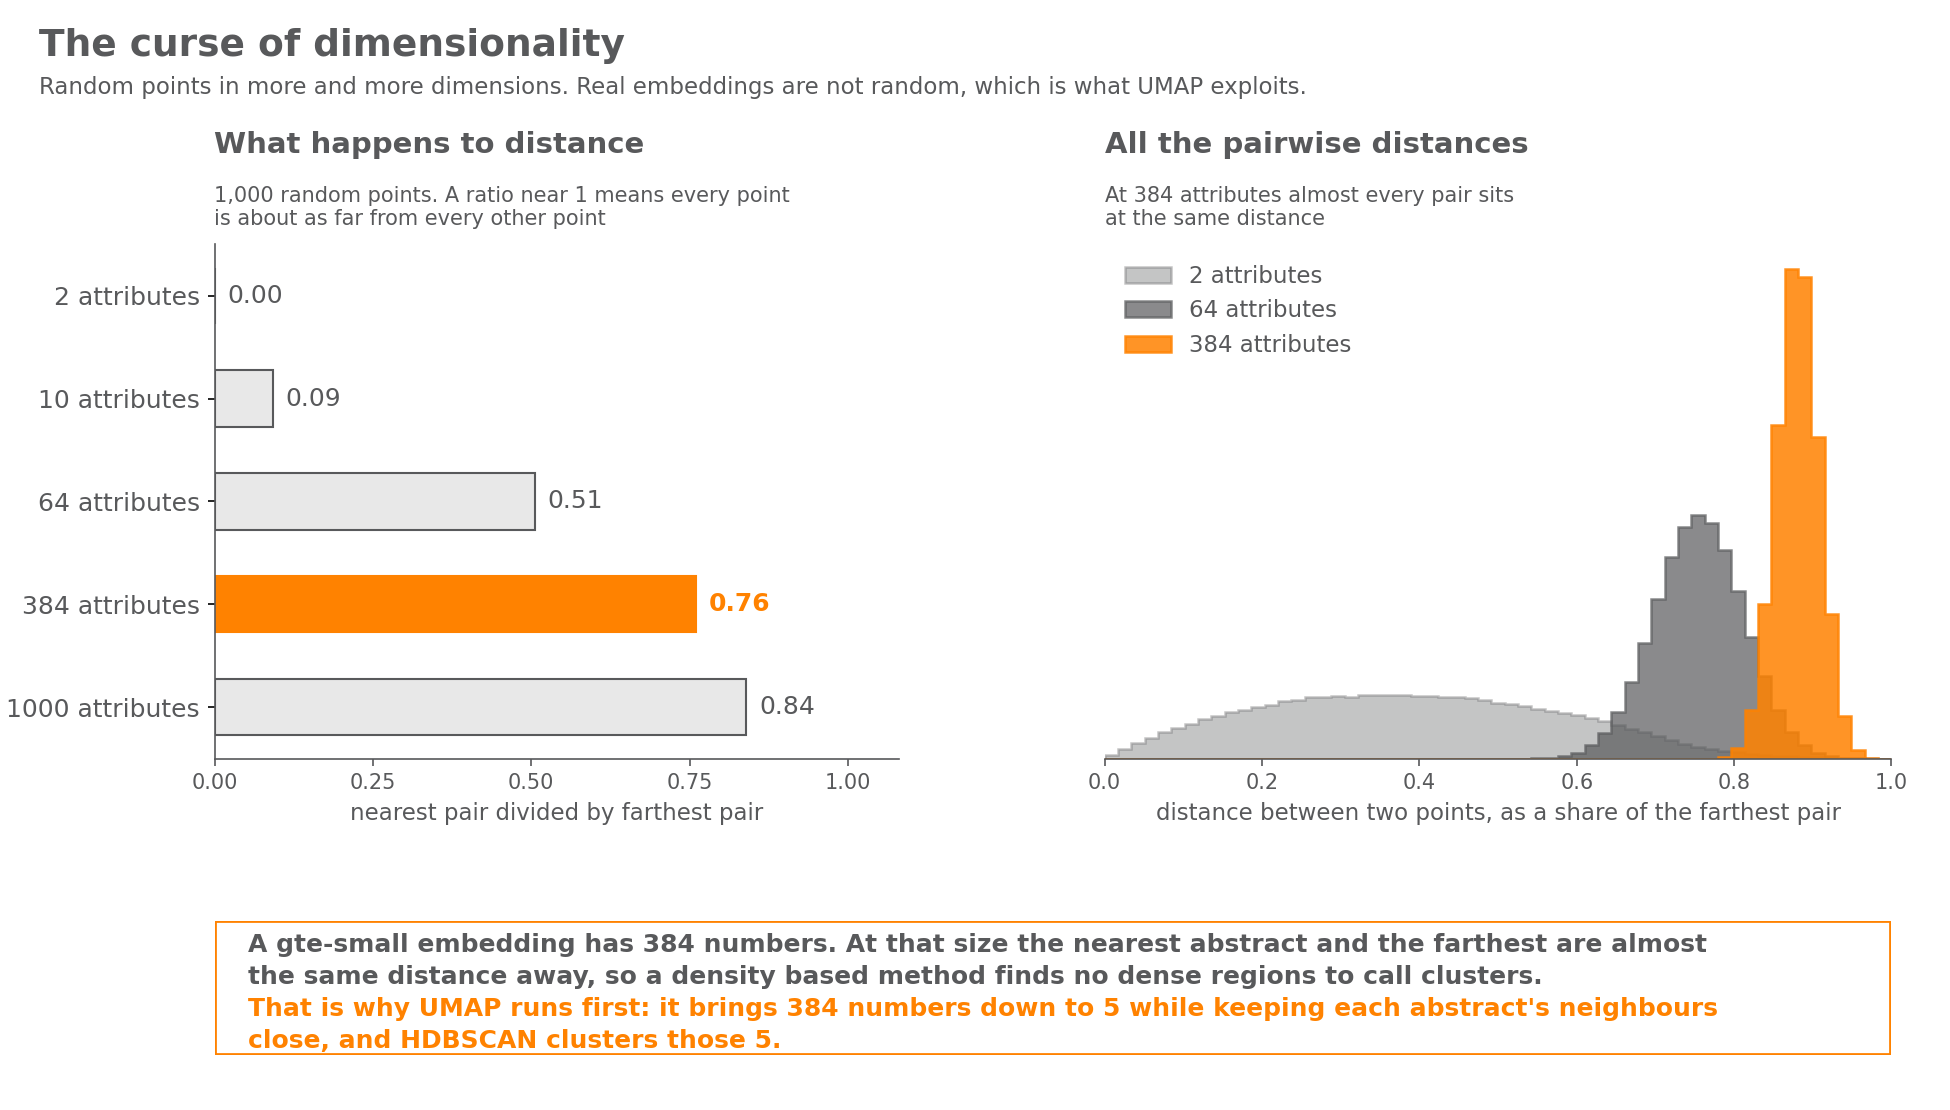

UMAP reduces the 384 numbers to a few. It builds a graph that links each point to its nearest
neighbors, then projects the points into fewer dimensions so those neighbors stay close.

| Argument | Value | What it does |
|---|---|---|
| `n_components` | `5` | how many numbers each abstract keeps |
| `min_dist` | `0.0` | how tightly points may pack together; 0 lets similar points sit on top of each other, which helps clustering |
| `metric` | `"cosine"` | how closeness is measured in the original 384 numbers, the same measure as Module 3 |
| `random_state` | `42` | fixes UMAP's random choices so a rerun gives the same result |

> Interactive explainer: [Understanding UMAP](https://pair-code.github.io/understanding-umap/),
> from Google PAIR. Change `n_neighbors` and `min_dist` on real data and watch the map change.

- **Python note:** `fit_transform` learns the mapping from the data and applies it to the same data
  in one call. It returns a new array and leaves `embeddings` unchanged.

> **Predict before running.**
>
> Going from 384 numbers to 5 discards most of each vector. What do you expect to be lost, and what
> do you expect to survive?

**Your prediction:**

_Type here._

> **Type this yourself.**
>
> ```python
> from umap import UMAP
> 
> umap_model = UMAP(n_components=5, min_dist=0.0, metric="cosine", random_state=42)
> 
> # learn the 5 dimensional map from the embeddings and apply it
> reduced_embeddings = umap_model.fit_transform(embeddings)
> 
> print("before:", embeddings.shape)
> print("after:", reduced_embeddings.shape)
> print("first abstract, reduced:", np.round(reduced_embeddings[0], 3))
> ```

In [ ]:
# Type the UMAP cell above here, then run it.


**Interpret the output.**

1. Look at the five numbers for the first abstract. Say whether any one of them means something on
   its own, and what that implies about how you can use the reduced vectors.
2. Suppose you removed `random_state` and reran this cell and the next one. Say what would change in
   the clusters and what that means for a result you report to someone else.

**Your answer:**

_Type here._

---

## Part 4 · HDBSCAN

HDBSCAN groups points that sit in dense regions and leaves points in sparse regions unassigned.

1. It measures how crowded the space around each point is.
2. It links points in crowded regions into groups.
3. It keeps a group as a cluster only if it has at least `min_cluster_size` points.
4. Every point that does not end up in a cluster gets the label `-1`, an outlier.

k-means, which you met in AI 102 or ITS 201, needs the number of clusters in advance and puts every
point in one. HDBSCAN needs neither: you set the smallest group it will call a cluster, and it
decides how many clusters there are and which points belong to none. The appendix runs k-means on
these same vectors so you can compare.

| Argument | Value | What it does |
|---|---|---|
| `min_cluster_size` | `20` | the smallest group that counts as a cluster |
| `metric` | `"euclidean"` | straight line distance, applied to the 5 UMAP numbers |
| `cluster_selection_method` | `"eom"` | the default rule for choosing between a large cluster and the smaller clusters inside it; it favours clusters that stay together across many density levels |

The textbook uses `min_cluster_size=50` on all 44,949 abstracts. With 5,000, a cluster of 50 would
need about nine times the share of the corpus, so we use 20.

> How it works, with pictures: [How HDBSCAN Works](https://hdbscan.readthedocs.io/en/latest/how_hdbscan_works.html).

- **Python note:** `set(clusters)` keeps one copy of each label, and `discard(-1)` removes the
  outlier label if it is there, so `len` gives the number of real clusters. `value_counts` counts
  how many times each label appears, largest first.

> **Predict before running.**
>
> 1. How many clusters will HDBSCAN find in 5,000 abstracts?
> 2. What share of the abstracts will it leave as outliers?

**Your prediction:**

_Type here._

> **Type this yourself.**
>
> ```python
> from hdbscan import HDBSCAN
> 
> hdbscan_model = HDBSCAN(min_cluster_size=20, metric="euclidean", cluster_selection_method="eom")
> hdbscan_model.fit(reduced_embeddings)
> 
> # one label per abstract, -1 marks an outlier
> clusters = hdbscan_model.labels_
> ```

In [ ]:
# Type the HDBSCAN lines above here, then run it.


The cell below counts the clusters and outliers from the labels you just made.

In [ ]:
cluster_ids = set(clusters)
cluster_ids.discard(-1)
n_clusters = len(cluster_ids)

# count the outliers one label at a time
n_outliers = 0
for label in clusters:
    if label == -1:
        n_outliers = n_outliers + 1

print("clusters:", n_clusters)
print("outliers:", n_outliers, "of", len(clusters))
print("outlier share:", round(n_outliers / len(clusters), 3))
print()

# the ten largest clusters, leaving out the outlier label
sizes = pd.Series(clusters).value_counts()
sizes = sizes.drop(-1, errors="ignore")
print("abstracts in the ten largest clusters:")
print(sizes.head(10))

**Interpret the output.**

1. Record the number of clusters and the outlier share. HDBSCAN refused to place the outliers
   anywhere. Say what that costs you if every abstract needs a group, for example to route it to a
   reviewer, and what it gains you if you only need the groups to be clean.
2. You chose the smallest cluster size, not the number of clusters. For a corpus you have never
   seen, say which of the two is easier to choose and why.

**Your answer:**

_Type here._

---

## Part 5 · Reading the clusters

With no labels, reading is how you check a cluster. The function below prints the title and the
first 300 characters of the first few abstracts with a given cluster label. The cluster numbers
come from HDBSCAN and do not follow size, so cluster 0 is not the largest.

> **Predict before running.**
>
> Will the three abstracts in one cluster share words, or only a subject?

**Your prediction:**

_Type here._

In [ ]:
def show_cluster(cluster_id, n=3):
    """Print the title and the start of the first n abstracts in one cluster."""
    shown = 0
    for i in range(len(clusters)):
        if clusters[i] == cluster_id:
            print(titles[i])
            print(abstracts[i][:300])
            print()
            shown = shown + 1
            if shown == n:
                break


print("CLUSTER 0")
print()
show_cluster(0)

print("CLUSTER 1")
print()
show_cluster(1)

**Interpret the output.**

1. Give each of the two clusters a name of two or three words. Say what in the abstracts told you.
2. Check your prediction from Part 1. Did any of your three research areas appear here or in the
   list of largest clusters, and if not, what would you have to do to find out whether it exists?

**Your answer:**

_Type here._

> **Your turn.**
>
> Pick one of the ten largest clusters from Part 4 and call `show_cluster` on it. Then call
> `show_cluster(-1)` to read three outliers. Say whether the outliers look like bad data, abstracts
> that span two topics, or topics too small to reach 20.

In [ ]:
# Your turn: read one large cluster and three outliers.

---

## Part 6 · A picture of the clusters

Five numbers per abstract cannot be plotted, so we run UMAP a second time with `n_components=2`,
only to draw the picture. The clusters still come from Part 4. The colours are the HDBSCAN labels,
so the clustering chose them, not us; outliers are grey. With many clusters the colour map repeats,
so two clusters far apart can share a colour.

The 2D map is a separate reduction from the 5D one. Distances in it are a rough guide.

The first plot is a still picture. The second draws the same points with Plotly, which you can zoom
and hover over.

- **Python note:** `plot_df[plot_df["cluster"] == -1]` keeps only the rows where the condition is
  true. The two `scatter` calls draw the outliers first, so the clusters sit on top.

> **Predict before running.**
>
> Will the outliers form their own region of the plot, or sit scattered between the clusters?

**Your prediction:**

_Type here._

In [ ]:
# a second, 2 dimensional reduction, used only for the plot
umap_2d = UMAP(n_components=2, min_dist=0.0, metric="cosine", random_state=42)
points_2d = umap_2d.fit_transform(embeddings)

plot_df = pd.DataFrame(points_2d, columns=["x", "y"])
plot_df["cluster"] = clusters

outliers_df = plot_df[plot_df["cluster"] == -1]
clustered_df = plot_df[plot_df["cluster"] != -1]

plt.figure(figsize=(8, 8))
plt.scatter(outliers_df["x"], outliers_df["y"], s=3, c="grey", alpha=0.2)
plt.scatter(clustered_df["x"], clustered_df["y"], s=3, c=clustered_df["cluster"], cmap="tab20", alpha=0.7)
plt.axis("off")
plt.title("5,000 abstracts, coloured by HDBSCAN cluster, outliers in grey")
plt.show()

The interactive version adds the title and year of each abstract, so you can read a region of the
map without leaving the plot:

- Hover over a point to see its title, year and cluster.
- Drag a box to zoom in, and double click to zoom back out.
- Click a cluster in the legend to hide it. Double click a cluster to show only that one.

- **Python note:** `px.scatter` draws one point per row of a DataFrame. `color="cluster"` colours by
  that column, and turning the labels into text with `astype(str)` gives each cluster its own
  colour and legend entry instead of a shade on one scale. `hover_data` lists the columns shown on
  hover, with `False` for the ones to hide.

In [ ]:
import plotly.express as px

# the same 2D points, plus the text to show on hover
hover_df = plot_df.copy()
hover_df["title"] = titles
hover_df["year"] = years

# cluster labels as text, so each cluster is its own colour and legend entry
hover_df["cluster"] = hover_df["cluster"].astype(str)

# legend order: -1 first, then 0, 1, 2 and so on
legend_order = []
for label in sorted(set(clusters)):
    legend_order.append(str(label))

fig = px.scatter(
    hover_df,
    x="x",
    y="y",
    color="cluster",
    category_orders={"cluster": legend_order},
    color_discrete_map={"-1": "lightgrey"},
    hover_data={"title": True, "year": True, "cluster": True, "x": False, "y": False},
    opacity=0.7,
    width=900,
    height=750,
    title="5,000 abstracts by HDBSCAN cluster, outliers (-1) in grey",
)
fig.update_traces(marker={"size": 4})
fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)
fig.show()

**Interpret the output.**

1. Say where the grey points sit, and what that suggests about why HDBSCAN left them out.
2. In the interactive plot, zoom into a place where two clusters touch and hover over points on
   each side. From the titles, say whether the two topics are related, and whether touching on the
   map was a good guide to that.
3. Hover over a few grey points near a cluster's edge. Say whether HDBSCAN was right to leave them
   out.

**Your answer:**

_Type here._

---

## Part 7 · Changing min_cluster_size

`min_cluster_size` is the one setting HDBSCAN needs. The loop below refits HDBSCAN with four values
on the same reduced vectors and records the number of clusters, the outlier share and the silhouette
score for each. UMAP does not run again, so this is fast.

This dataset has no labels, so ARI and NMI cannot be computed here; Part 0, Part 7 shows them on the
digits. The silhouette score needs no labels: for each clustered abstract it compares the distance to
its own cluster with the distance to the nearest other cluster, from -1 to 1, higher is better.
Outliers are left out of it.

- **Python note:** each pass of the loop adds one dictionary to `rows`, and `pd.DataFrame(rows)`
  turns the list of dictionaries into a table with one row per value.

> **Predict before running.**
>
> As `min_cluster_size` goes from 10 to 100, which way will the number of clusters move, and which
> way will the outlier share move?

**Your prediction:**

_Type here._

In [ ]:
from sklearn.metrics import silhouette_score

rows = []

for size in [10, 20, 50, 100]:
    model = HDBSCAN(min_cluster_size=size, metric="euclidean", cluster_selection_method="eom")
    labels = model.fit(reduced_embeddings).labels_

    ids = set(labels)
    ids.discard(-1)

    outliers = 0
    kept_points = []
    kept_labels = []
    for i in range(len(labels)):
        if labels[i] == -1:
            outliers = outliers + 1
        else:
            kept_points.append(reduced_embeddings[i])
            kept_labels.append(labels[i])

    rows.append({
        "min_cluster_size": size,
        "clusters": len(ids),
        "outliers": outliers,
        "outlier share": round(outliers / len(labels), 3),
        "silhouette": round(silhouette_score(kept_points, kept_labels), 3),
    })

sweep = pd.DataFrame(rows)
sweep

**Interpret the output.**

1. Describe what one setting traded against another. Did the outlier share move the way you
   predicted, and if not, what would explain it?
2. A support team wants about ten themes from its tickets. A researcher wants every small subtopic.
   Say which value from the table you would give each, and what each of them gives up.
3. Did the silhouette score rise or fall as the clusters got fewer? Say why a better silhouette does
   not mean the clusters are better topics.

**Your answer:**

_Type here._

---

## Check yourself

- Name the three steps of the pipeline and what each one hands to the next.
- Say why HDBSCAN runs on the UMAP output rather than on the 384 numbers.
- Say what k-means needs that HDBSCAN does not, and what HDBSCAN does that k-means cannot.
- Say what the label `-1` means and which setting controls how many abstracts get it.
- Say which clustering scores you can compute without labels, and which need them.

## Summary

An embedding model turns each abstract into a vector. UMAP reduces the vectors to a few numbers
while keeping neighbours close. HDBSCAN groups the dense regions into clusters.

HDBSCAN decides how many clusters there are and leaves points in sparse regions as outliers.
`min_cluster_size` trades the number of clusters against the share of outliers.

With no labels, reading a cluster is how you check it.

---

## Appendix · k-means on the same vectors, optional

Nothing here is needed for Part 2 of this lab. It runs the method you already know on the Part 3
vectors and compares it with HDBSCAN.

### A1 · k-means

k-means, from AI 102 or ITS 201, takes a number of clusters k, places k centres, and assigns every
point to its nearest centre. It moves the centres and repeats until nothing changes. Every point
ends up in a cluster. Nothing is left out.

The catch is k. There is no label here that says how many research areas the 5,000 abstracts
cover, so any k is a guess. We guess 20.

- **Python note:** `fit_predict` fits k-means and returns one cluster number per abstract.
  `n_init=10` runs k-means from ten random starts and keeps the best, since one start can land badly.
  `value_counts` counts how many abstracts got each cluster number, largest first.

> **Predict before running.**
>
> 1. With k set to 20, will the 20 clusters be roughly equal in size, or will a few be large and
>    many small?
> 2. An abstract that belongs to no research area in the corpus. Where will k-means put it?

**Your prediction:**

_Type here._

In [ ]:
from sklearn.cluster import KMeans

kmeans_model = KMeans(n_clusters=20, random_state=42, n_init=10)

# one cluster number per abstract, every abstract gets one
kmeans_labels = kmeans_model.fit_predict(reduced_embeddings)

kmeans_sizes = pd.Series(kmeans_labels).value_counts()
print("k-means clusters:", len(kmeans_sizes))
print("smallest and largest cluster:", kmeans_sizes.min(), kmeans_sizes.max())
print()
print("abstracts per cluster:")
print(kmeans_sizes)

**Interpret the output.**

1. You set k to 20 with no evidence. Say what you would look at in this output, or elsewhere, to
   decide whether 20 was too many or too few, and why none of it settles the question.
2. Every abstract got a cluster. Say what that does to a cluster's quality when the corpus holds
   abstracts that belong to no group, and what you would want the method to do with those instead.

**Your answer:**

_Type here._

### A2 · Comparing the two clusterings

A1 and Part 4 clustered the same 5 number vectors. k-means gave every abstract one of 20
clusters. HDBSCAN chose its own number of clusters and left some abstracts out.

To compare the two groupings we use the adjusted Rand index. It looks at every pair of documents
and asks whether both methods put the pair together or both put it apart. A score of 1.0 means the
two groupings are identical, a score near 0 means they agree no more than chance would. It ignores
the cluster numbers, so cluster 3 in one method can match cluster 17 in the other. HDBSCAN outliers
are left out, since k-means has no outlier group to match them with.

With true labels, the same call compares clusters against the labels. The two groupings need not
have the same number of clusters.

With no labels there is a second kind of score, computed from the vectors and the cluster labels
alone:

| Score | What it measures | Better |
|---|---|---|
| Silhouette | for each point, how close it is to its own cluster against the nearest other cluster; -1 to 1 | higher |
| Calinski-Harabasz | spread between cluster centres divided by spread inside clusters | higher |
| Davies-Bouldin | for each cluster, how similar it is to the cluster most like it | lower |

All three are computed on the 5 UMAP numbers, and HDBSCAN's outliers are left out, since a group of
leftovers is not a cluster.

- **Python note:** the three scoring functions take the vectors and the labels in that order. The
  loop below builds one dictionary per method and `pd.DataFrame(rows)` shows them as a table.

> **Predict before running.**
>
> 1. On the abstracts HDBSCAN did cluster, will k-means mostly agree with it?
> 2. Where will k-means put the abstracts HDBSCAN called outliers?
> 3. Which method will score better on the three unlabelled scores, and why?

**Your prediction:**

_Type here._

In [ ]:
from sklearn.metrics import adjusted_rand_score

print("k-means clusters:", len(kmeans_sizes), "| HDBSCAN clusters:", n_clusters)
print()

# keep only the abstracts HDBSCAN placed in a cluster
hdbscan_kept = []
kmeans_kept = []
for i in range(len(clusters)):
    if clusters[i] != -1:
        hdbscan_kept.append(clusters[i])
        kmeans_kept.append(kmeans_labels[i])

score = adjusted_rand_score(hdbscan_kept, kmeans_kept)
print("adjusted Rand index, clustered abstracts only:", round(score, 3))
print()

# where k-means put the first five HDBSCAN outliers
print("HDBSCAN outliers and their k-means cluster:")
shown = 0
for i in range(len(clusters)):
    if clusters[i] == -1:
        print("k-means cluster", kmeans_labels[i], "|", titles[i])
        shown = shown + 1
        if shown == 5:
            break

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# HDBSCAN scored on the abstracts it clustered, k-means on all of them
kept = clusters != -1

rows = []
for name, vectors, labels in [
    ("k-means, k=20", reduced_embeddings, kmeans_labels),
    ("HDBSCAN, outliers left out", reduced_embeddings[kept], clusters[kept]),
]:
    rows.append({
        "method": name,
        "abstracts scored": len(labels),
        "silhouette": round(silhouette_score(vectors, labels), 3),
        "Calinski-Harabasz": round(calinski_harabasz_score(vectors, labels), 1),
        "Davies-Bouldin": round(davies_bouldin_score(vectors, labels), 3),
    })

pd.DataFrame(rows)

**Interpret the output.**

1. Compare the k-means cluster sizes from A1 with the HDBSCAN sizes from Part 4. Say what
   k-means did with the abstracts HDBSCAN left out, and what that means for the score.
2. Read the five outlier titles. Pick one and say whether placing it in a cluster is useful or
   misleading, and what you would need to read to decide.
3. The three unlabelled scores were computed on the UMAP output, and UMAP with `min_dist=0.0` was
   told to pack each group tight. Say what a good score does and does not tell you about whether
   the clusters are real research areas, and what you would do to find out.
4. The midterm corpus comes with true labels. Say what the outliers would do to an adjusted Rand
   index computed against those labels, and how you would report the score so a reader is not
   misled.

**Your answer:**

_Type here._

## References

- Alammar and Grootendorst, *Hands-On Large Language Models*, Chapter 5, Text Clustering and Topic
  Modeling. This notebook is adapted from the book's Chapter 5 notebook, run on a 5,000 abstract
  sample.
- The book's Chapter 5 notebook:
  [on GitHub](https://github.com/HandsOnLLM/Hands-On-Large-Language-Models/blob/main/chapter05/Chapter%205%20-%20Text%20Clustering%20and%20Topic%20Modeling.ipynb)
- Dataset card: [maartengr/arxiv_nlp](https://huggingface.co/datasets/maartengr/arxiv_nlp)
- Model card: [thenlper/gte-small](https://huggingface.co/thenlper/gte-small)
- [Understanding UMAP](https://pair-code.github.io/understanding-umap/), Google PAIR
- [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/)
- [How HDBSCAN Works](https://hdbscan.readthedocs.io/en/latest/how_hdbscan_works.html)
- [sklearn KMeans reference](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- [sklearn adjusted_rand_score reference](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)
- [sklearn clustering performance evaluation](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation), silhouette, Calinski-Harabasz, Davies-Bouldin and the labelled scores